In [39]:
# Imports
import os, time, torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [40]:
import kagglehub
itsahmad_indoor_scenes_cvpr_2019_path = kagglehub.dataset_download('itsahmad/indoor-scenes-cvpr-2019')
basePath = itsahmad_indoor_scenes_cvpr_2019_path

rootDir = basePath + "/indoorCVPR_09/Images"

In [41]:
# Dataset Loading + Transforms
# rootDir = '/kaggle/input/indoor-scenes-cvpr-2019/indoorCVPR_09/Images'

allData = []
for label in sorted(os.listdir(rootDir)):
    labelDir = os.path.join(rootDir, label)
    if os.path.isdir(labelDir):
        for file in os.listdir(labelDir):
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                allData.append((os.path.join(labelDir, file), label))

trainData, tempData = train_test_split(allData, test_size=0.2, stratify=[label for _, label in allData], random_state=42)
valData, testData = train_test_split(tempData, test_size=0.5, stratify=[label for _, label in tempData], random_state=42)

labelNames = sorted(set(label for _, label in allData))
labelToIndex = {label: idx for idx, label in enumerate(labelNames)}

print(f"Train: {len(trainData)}, Val: {len(valData)}, Test: {len(testData)}")


Train: 12496, Val: 1562, Test: 1562


In [42]:
# Dataset + Transforms
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

trainTransform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.3, 0.3, 0.2),
    transforms.RandomAffine(15, shear=10),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

class SceneDataset(Dataset):
    def __init__(self, data, transform):
        self.data = data
        self.transform = transform

    def __getitem__(self, idx):
        imgPath, label = self.data[idx]
        image = Image.open(imgPath).convert('RGB')
        image = self.transform(image)
        return image, labelToIndex[label]

    def __len__(self):
        return len(self.data)

trainLoader = DataLoader(SceneDataset(trainData, trainTransform), batch_size=64, shuffle=True)
valLoader = DataLoader(SceneDataset(valData, transform), batch_size=64)
testLoader = DataLoader(SceneDataset(testData, transform), batch_size=64)

# fine_label_to_idx = {label: idx for idx, label in enumerate(fine_label_names)}

In [43]:
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.shape
        se = self.pool(x).view(b, c)
        se = self.fc(se).view(b, c, 1, 1)
        return x * se
    


class FosNet(nn.Module):
    def __init__(self, num_classes=67):
        super(FosNet, self).__init__()

        # Block 1: Low-level features
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # Input: [3, 224, 224] → [32, 224, 224]
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)                              # → [32, 112, 112]
        )

        # Block 2: Mid-level features
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # → [64, 112, 112]
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)                              # → [64, 56, 56]
        )

        # Block 3: High-level features
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),# → [128, 56, 56]
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)                              # → [128, 28, 28]
        )

        # Block 4: Deeper abstraction
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),# → [256, 28, 28]
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)                               # → [256, 14, 14]
        )

        # Block 5: Final feature encoding
        self.block5 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1),# → [512, 14, 14]
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)                       # → [512, 1, 1]
        )

        # Classification head
        self.classifier = nn.Sequential(
            nn.Flatten(),                                  # → [512]
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)                   # → [67]
        )

    def forward(self, x):
        x = self.block1(x)  # [B, 3, 224, 224] → [B, 32, 112, 112]
        x = self.block2(x)  # → [B, 64, 56, 56]
        x = self.block3(x)  # → [B, 128, 28, 28]
        x = self.block4(x)  # → [B, 256, 14, 14]
        x = self.block5(x)  # → [B, 512, 1, 1]
        x = self.classifier(x)
        return x

    # fosnet_best_model

In [44]:
# efficient net
class MiniEfficientNet(nn.Module):
    def __init__(self, num_classes=67):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.SiLU()
        )

        def MBConv(in_c, out_c, expand=6, stride=1):
            hidden = in_c * expand
            return nn.Sequential(
                nn.Conv2d(in_c, hidden, 1, bias=False), nn.BatchNorm2d(hidden), nn.SiLU(),
                nn.Conv2d(hidden, hidden, 3, stride=stride, padding=1, groups=hidden, bias=False),
                nn.BatchNorm2d(hidden), nn.SiLU(),
                SEBlock(hidden),
                nn.Conv2d(hidden, out_c, 1, bias=False), nn.BatchNorm2d(out_c)
            )

        self.blocks = nn.Sequential(
            MBConv(32, 16, expand=1),
            MBConv(16, 24, stride=2),
            MBConv(24, 40, stride=2),
            MBConv(40, 80, stride=2),
            MBConv(80, 112),
            MBConv(112, 192, stride=2),
            MBConv(192, 320)
        )

        self.head = nn.Sequential(
            nn.Conv2d(320, 1280, 1, bias=False), nn.BatchNorm2d(1280), nn.SiLU(),
            nn.AdaptiveAvgPool2d(1)
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Flatten(),
            nn.Linear(1280, num_classes)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.blocks(x)
        x = self.head(x)
        return self.classifier(x)

In [45]:
class SoftEnsemble(torch.nn.Module):
    def __init__(self, model1, model2):
        super(SoftEnsemble, self).__init__()
        self.model1 = model1
        self.model2 = model2

    def forward(self, x):
        out1 = F.softmax(self.model1(x), dim=1)
        out2 = F.softmax(self.model2(x), dim=1)
        return (out1 + out2) / 2

In [50]:
import torch
import torch.nn.functional as F
from sklearn.metrics import classification_report
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = 67


model_effnet =  MiniEfficientNet().to(device)
model_fosnet = FosNet(num_classes=num_classes).to(device)

model_effnet.load_state_dict(torch.load("project_sarayusi_vishalim_efficientnet_student.pth", map_location=device))
model_fosnet.load_state_dict(torch.load("project_sarayusi_vishalim_fosnet_student.pth", map_location=device))

model_effnet = model_effnet.to(device)
model_fosnet = model_fosnet.to(device)


model_effnet.eval()
model_fosnet.eval()

def soft_ensemble_predict(imgs, model1, model2):
    with torch.no_grad():
        out1 = F.softmax(model1(imgs), dim=1)
        out2 = F.softmax(model2(imgs), dim=1)
        return (out1 + out2) / 2

def evaluate_ensemble(model1, model2, dataloader, label_names):
    all_preds = []
    all_labels = []

    for imgs, labels in tqdm(dataloader, desc="Evaluating Ensemble"):
        imgs = imgs.to(device)
        labels = labels.to(device)

        outputs = soft_ensemble_predict(imgs, model1, model2)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    print("\nClassification Report (Ensemble):")
    df_report = classification_report(all_labels, all_preds, target_names=label_names)
    print(df_report)

def weighted_soft_ensemble(imgs, model1, model2, w1=0.7, w2=0.3):
    with torch.no_grad():
        out1 = F.softmax(model1(imgs), dim=1)
        out2 = F.softmax(model2(imgs), dim=1)
        combined = (w1 * out1 + w2 * out2) / (w1 + w2)
        return combined
def evaluate_weighted_ensemble(model1, model2, dataloader, label_names, w1=0.7, w2=0.3):
    all_preds = []
    all_labels = []

    for imgs, labels in tqdm(dataloader, desc="Evaluating Weighted Ensemble"):
        imgs = imgs.to(device)
        labels = labels.to(device)

        outputs = weighted_soft_ensemble(imgs, model1, model2, w1=w1, w2=w2)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    print("\nWeighted Soft Voting Ensemble Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=label_names))


idx_to_label = {idx: label for label, idx in labelToIndex.items()}

label_names = [idx_to_label[i] for i in range(num_classes)]
evaluate_ensemble(model_effnet, model_fosnet, valLoader, label_names)

# ensemble_model = SoftEnsemble(model_effnet, model_fosnet).to(device)
# ensemble_model.eval()

# evaluate_ensemble(ensemble_model, valLoader, label_names)
evaluate_weighted_ensemble(model_effnet, model_fosnet, valLoader, label_names, w1=0.8, w2=0.2)

torch.save(model_effnet.state_dict(), "project_sarayusi_vishalim_ensemble_effnet.pth")
torch.save(model_fosnet.state_dict(), "project_sarayusi_vishalim_ensemble_fosnet.pth")

Evaluating Ensemble: 100%|██████████| 25/25 [00:54<00:00,  2.17s/it]



Classification Report (Ensemble):
                     precision    recall  f1-score   support

     airport_inside       0.71      0.69      0.70        61
          artstudio       1.00      0.29      0.44        14
         auditorium       0.80      0.89      0.84        18
             bakery       0.86      0.60      0.71        40
                bar       0.60      0.72      0.65        60
           bathroom       0.81      0.68      0.74        19
            bedroom       0.73      0.58      0.64        66
          bookstore       0.83      0.66      0.74        38
            bowling       0.82      0.86      0.84        21
             buffet       0.77      0.91      0.83        11
             casino       0.83      0.94      0.88        52
      children_room       0.90      0.82      0.86        11
      church_inside       0.75      0.83      0.79        18
          classroom       0.91      0.83      0.87        12
           cloister       0.92      1.00      0.9

Evaluating Weighted Ensemble: 100%|██████████| 25/25 [00:51<00:00,  2.07s/it]


Weighted Soft Voting Ensemble Classification Report:
                     precision    recall  f1-score   support

     airport_inside       0.76      0.69      0.72        61
          artstudio       1.00      0.29      0.44        14
         auditorium       0.82      0.78      0.80        18
             bakery       0.86      0.62      0.72        40
                bar       0.67      0.70      0.68        60
           bathroom       0.82      0.74      0.78        19
            bedroom       0.74      0.56      0.64        66
          bookstore       0.93      0.66      0.77        38
            bowling       0.82      0.86      0.84        21
             buffet       0.71      0.91      0.80        11
             casino       0.89      0.94      0.92        52
      children_room       0.79      1.00      0.88        11
      church_inside       0.67      0.89      0.76        18
          classroom       0.92      0.92      0.92        12
           cloister       0.86

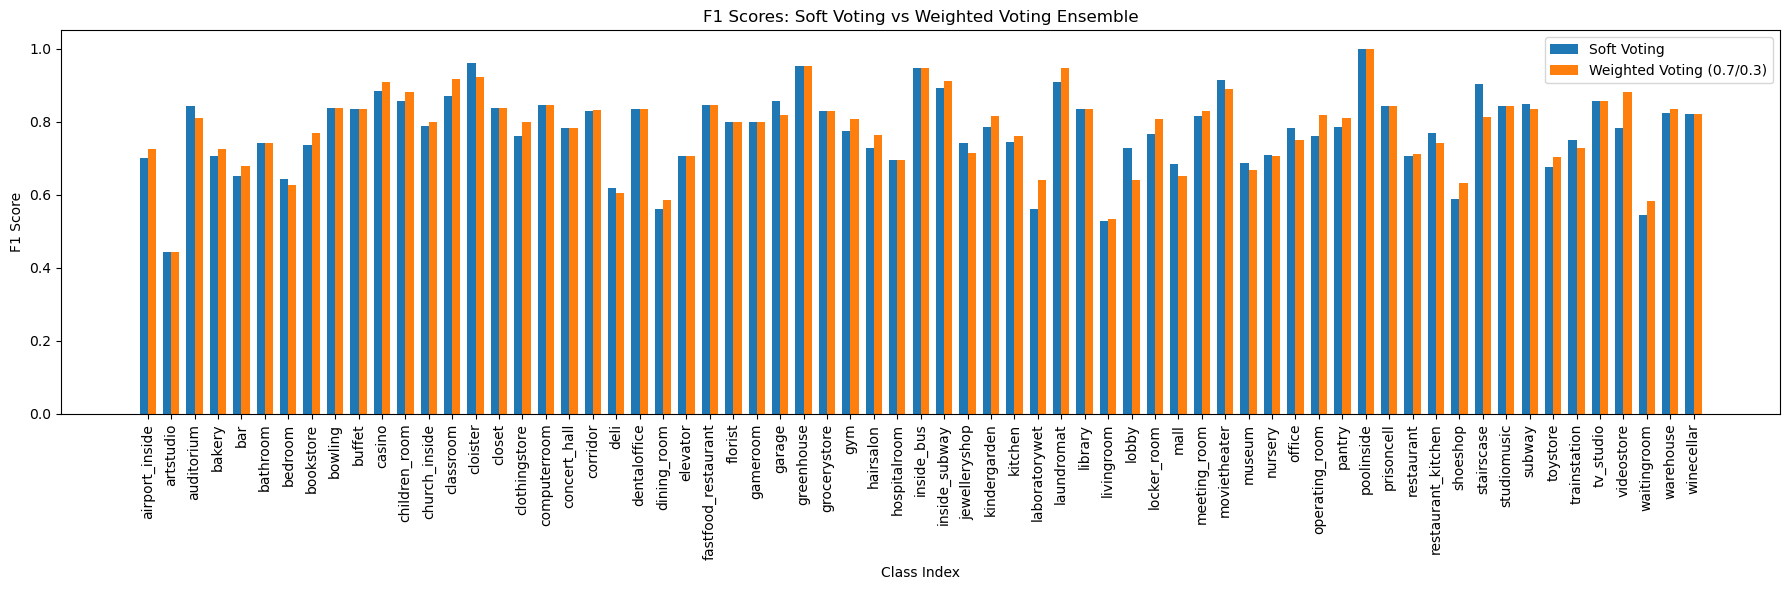

In [48]:
def soft_ensemble(imgs, model1, model2):
    with torch.no_grad():
        out1 = F.softmax(model1(imgs), dim=1)
        out2 = F.softmax(model2(imgs), dim=1)
        return (out1 + out2) / 2

# Weighted voting ensemble
def weighted_ensemble(imgs, model1, model2, w1=0.7, w2=0.3):
    with torch.no_grad():
        out1 = F.softmax(model1(imgs), dim=1)
        out2 = F.softmax(model2(imgs), dim=1)
        return (w1 * out1 + w2 * out2) / (w1 + w2)

def get_f1_scores(dataloader, model1, model2, ensemble_fn):
    all_preds = []
    all_labels = []
    for imgs, labels in dataloader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = ensemble_fn(imgs, model1, model2)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    report = classification_report(all_labels, all_preds, target_names=label_names, output_dict=True)
    return [report[label]["f1-score"] for label in label_names]

f1_soft = get_f1_scores(valLoader, model_effnet, model_fosnet, soft_ensemble)
f1_weighted = get_f1_scores(valLoader, model_effnet, model_fosnet, lambda x, m1, m2: weighted_ensemble(x, m1, m2, 0.7, 0.3))

# F1-score comparison
x = np.arange(len(label_names))
width = 0.35
plt.figure(figsize=(18, 6))
plt.bar(x - width/2, f1_soft, width, label='Soft Voting')
plt.bar(x + width/2, f1_weighted, width, label='Weighted Voting (0.7/0.3)')
plt.xlabel('Class Index')
plt.ylabel('F1 Score')
plt.title('F1 Scores: Soft Voting vs Weighted Voting Ensemble')
plt.xticks(ticks=x, labels=label_names, rotation=90)
plt.legend()
plt.tight_layout()
plt.show()